<h1>Ensemble methods<h1>

In [4]:
import numpy as np
from sklearn.datasets import load_wine
X=load_wine()
# Set random seed for reproducibility
np.random.seed(1)
data = load_wine()
X = data.data
y = data.target

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier,GradientBoostingClassifier

b_estim=50
min_samp=3
max_depth=1
random=1
bag=BaggingClassifier(n_estimators=b_estim,random_state=random)
adab=AdaBoostClassifier(n_estimators=b_estim,algorithm='SAMME',random_state=random,learning_rate = 1.0)
grad=GradientBoostingClassifier(min_samples_leaf=min_samp,n_estimators=b_estim,learning_rate= 1.0,subsample= 0.5,random_state=random,max_depth=max_depth)
dtree=DecisionTreeClassifier(min_samples_split=min_samp,random_state=random)

ense=[bag,adab,grad]

In [16]:
from sklearn.model_selection import cross_val_score,StratifiedKFold

skf=StratifiedKFold(n_splits=5, random_state=1, shuffle=True)
skf=5
score=[cross_val_score(dtree, X,y, cv=skf)]
for i in ense:
  i.fit(X,y)
  score.append(cross_val_score(i, X,y, cv=skf))

In [19]:
s=['DecisionTreeClassifier','BaggingClassifier','AdaBoostClassifier','GradientBoostingClassifier']
print('Kolejno dla',s)
for i in score:
    print(i,'AVG :', np.mean(i))

Kolejno dla ['DecisionTreeClassifier', 'BaggingClassifier', 'AdaBoostClassifier', 'GradientBoostingClassifier']
[0.91666667 0.80555556 0.94444444 0.91428571 0.85714286] AVG : 0.8876190476190476
[0.94444444 0.94444444 0.94444444 0.97142857 1.        ] AVG : 0.9609523809523809
[0.83333333 0.91666667 0.91666667 1.         1.        ] AVG : 0.9333333333333332
[0.91666667 0.97222222 0.97222222 0.42857143 0.97142857] AVG : 0.8522222222222222


Gradient Boosting iteration treshold

Text(0, 0.5, 'Comulative Improvement')

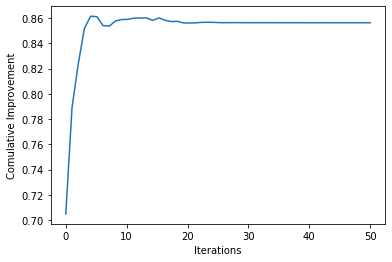

In [26]:
import matplotlib.pyplot as plt 
iterr = np.cumsum(grad.oob_improvement_)
iters = np.linspace(0, len(iterr), 50)
plt.plot(iters, iterr)
plt.xlabel('Iterations')
plt.ylabel('Comulative Improvement')